# Notebook 11 - OPPS Medicare FFS Reference Rung (ladder v1.1)

**Purpose.** Add a *true* Medicare Fee-For-Service rung to the DFW hospital pricing ladder,
sourced from the CMS Hospital OPPS (Outpatient Prospective Payment System) Addendum B, for CPT 73721.
This is proposed to replace the peer-borrowed Medicare Advantage (MA) proxy as the *primary* Medicare
reference (see Findings and the proposed Decision 33 at the bottom).

**Why a separate rung type.** The OPPS rate is a published national constant per code per year,
identical for every hospital. It is therefore a *reference* rung (one benchmark line across all
hospitals), not a per-hospital *query* rung like the negotiated commercial / MA rates. It does not
touch the DB and does not belong in `queries.py`.

**Status: UNCONFIRMED.** The national rate below ($243.77) came from a secondary fee-lookup, not the
CMS Addendum B file. The `confirmed` flag is `False` and a banner prints until the value is verified
against the actual CY2026 Addendum B line for 73721. The DFW CBSA wage index is also a placeholder
(`None`) until pulled.

**Run.** Restart & Run All. No DB connection, no dependency on the NB9 / NB10 kernels. All upstream
numbers (MCA commercial, peer-MA rungs) are carried in as documented constants with provenance.

## Step 0 - Setup

In [1]:
# Step 0 - Setup. DB-independent: no connection, no queries.py import needed.
import math
from datetime import date
from pathlib import Path
import pandas as pd

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Light project-root locator (non-fatal). NB11 does not read the DB, but we keep the
# repo-location convention so paths resolve if this is extended later.
def find_project_root(start=None, marker="dfw-hospital-pricing"):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if cand.name == marker or (cand / ".git").exists():
            return cand
    return None

PROJECT_ROOT = find_project_root()
print("project root:", PROJECT_ROOT if PROJECT_ROOT else "(not found - fine, NB11 is reference-only)")
print("setup ok")

project root: C:\Users\kedha\Documents\dfw-hospital-pricing
setup ok


## Step 1 - OPPS FFS reference table

A static reference keyed by `(cpt, rate_year)`. Add rows for basket / year growth later.
Confirm each rate against the CMS OPPS Addendum B file: column C = status indicator,
column D = APC, plus the payment-rate column.

In [2]:
# Step 1 - OPPS FFS reference table.
OPPS_FFS_REFERENCE = [
    {
        "cpt": "73721",
        "description": "MRI, lower-extremity joint, without contrast",
        "apc": "5523",
        "apc_title": "Level 3 Imaging without Contrast",
        "status_indicator": None,            # TODO confirm from Addendum B col C (likely 'S' or 'Q3')
        "national_rate_usd": 243.77,         # CY2026 national unadjusted; SECONDARY source - CONFIRM
        "rate_year": 2026,
        "includes_beneficiary_copay": True,  # Addendum B rate is total allowed (program + 20% copay)
        "source": "CY2026 OPPS Addendum B (secondary fee-lookup; confirm against CMS file)",
        "date_pulled": "2026-06-09",
        "confirmed": False,
    },
]

opps = pd.DataFrame(OPPS_FFS_REFERENCE)

def opps_rate(cpt, year):
    hit = opps[(opps.cpt == str(cpt)) & (opps.rate_year == year)]
    if hit.empty:
        raise KeyError(f"no OPPS reference row for cpt={cpt}, year={year}")
    return hit.iloc[0]

row = opps_rate("73721", 2026)
if not bool(row.confirmed):
    print("=" * 66)
    print("WARNING: OPPS rate is UNCONFIRMED (secondary source).")
    print(f"  73721 / APC {row.apc} / CY{row.rate_year} national = ${row.national_rate_usd:,.2f}")
    print("  Verify against CMS OPPS Addendum B, then set confirmed=True.")
    print("=" * 66)
opps

  73721 / APC 5523 / CY2026 national = $243.77
  Verify against CMS OPPS Addendum B, then set confirmed=True.


,cpt,description,apc,apc_title,status_indicator,national_rate_usd,rate_year,includes_beneficiary_copay,source,date_pulled,confirmed
0,73721,"MRI, lower-extremity joint, without contrast",5523,Level 3 Imaging without Contrast,None,243.77,2026,True,CY2026 OPPS Addendum B (secondary fee-lookup; ...,2026-06-09,False


## Step 2 - Wage adjustment (optional DFW variant)

OPPS wage-adjusts only the labor-related share (~60%); the rest is non-labor:

`adjusted = national * (labor_share * wage_index + (1 - labor_share))`

Headline uses the national unadjusted rate. The DFW variant stays pending until the
Dallas / Fort Worth CBSA wage index is supplied.

In [3]:
# Step 2 - Wage adjustment.
LABOR_SHARE = 0.60            # OPPS labor-related share (~60%); confirm exact for the rate year
DFW_CBSA_WAGE_INDEX = None    # TODO pull Dallas-Plano-Irving / Fort Worth CBSA OPPS wage index (CY2026)

def wage_adjust(national, wage_index, labor_share=LABOR_SHARE):
    if wage_index is None:
        return None
    return national * (labor_share * wage_index + (1.0 - labor_share))

national_73721 = float(row.national_rate_usd)
dfw_73721 = wage_adjust(national_73721, DFW_CBSA_WAGE_INDEX)

print(f"national unadjusted : ${national_73721:,.2f}")
if dfw_73721 is None:
    print("DFW wage-adjusted   : (pending - set DFW_CBSA_WAGE_INDEX)")
else:
    print(f"DFW wage-adjusted   : ${dfw_73721:,.2f}  (WI={DFW_CBSA_WAGE_INDEX}, labor share={LABOR_SHARE})")

national unadjusted : $243.77
DFW wage-adjusted   : (pending - set DFW_CBSA_WAGE_INDEX)


## Step 3 - Other ladder ingredients (documented constants)

Carried from prior notebooks, **not** recomputed here, so NB11 stays standalone and DB-free.
Provenance is in the comments. A small internal check guards against a typo in the peer-MA values.

In [4]:
# Step 3 - Other ladder ingredients, carried as documented constants.

# MCA commercial rung: NB9 (09_cash_vs_lob_ladder_4), single 'commercial' bucket,
# 15 dollar-priced rows, zero commercial_specialty, never family-pooled. Stable Day 13 -> Day 15.
MCA_COMMERCIAL_USD = 906.53

# Peer Medicare Advantage rungs for 73721: NB10 (10_mca_reconciliation) Step R real-run output.
PEER_MA = {
    "Baylor":     235.30,
    "Methodist":  232.47,
    "Parkland":  1274.07,   # high outlier
    "THP":        226.38,
}
PEER_MA_MEDIAN_ALL     = 233.88   # median of all four (NB10)
PEER_MA_MEDIAN_CLUSTER = 232.47   # Parkland outlier excluded (NB10)

# Internal check: recomputed medians match the carried constants.
_vals = sorted(PEER_MA.values())
_med_all = (_vals[1] + _vals[2]) / 2
_cluster = sorted(v for k, v in PEER_MA.items() if k != "Parkland")
_med_cluster = _cluster[len(_cluster) // 2]
assert abs(_med_all - PEER_MA_MEDIAN_ALL) < 0.01, (_med_all, PEER_MA_MEDIAN_ALL)
assert abs(_med_cluster - PEER_MA_MEDIAN_CLUSTER) < 0.01, (_med_cluster, PEER_MA_MEDIAN_CLUSTER)

print(f"MCA commercial       : ${MCA_COMMERCIAL_USD:,.2f}")
print(f"peer-MA median (all) : ${PEER_MA_MEDIAN_ALL:,.2f}")
print(f"peer-MA median (clu) : ${PEER_MA_MEDIAN_CLUSTER:,.2f}")
print("ingredient checks ok")

MCA commercial       : $906.53
peer-MA median (all) : $233.88
peer-MA median (clu) : $232.47
ingredient checks ok


## Step R - Reconciliation: commercial / Medicare multiple against the FFS rung

Compare the MCA commercial multiple computed against true FFS to the prior peer-MA-based figure,
and report MA as a percent of FFS (the mirror finding).

In [5]:
# Step R - Recompute the multiple against FFS and compare to peer-MA.
def mult(numer, denom):
    return None if (denom is None or denom == 0) else numer / denom

rows = [
    ("FFS national (OPPS)",      national_73721,         mult(MCA_COMMERCIAL_USD, national_73721)),
    ("FFS DFW wage-adjusted",    dfw_73721,              mult(MCA_COMMERCIAL_USD, dfw_73721)),
    ("peer-MA median (all)",     PEER_MA_MEDIAN_ALL,     mult(MCA_COMMERCIAL_USD, PEER_MA_MEDIAN_ALL)),
    ("peer-MA median (cluster)", PEER_MA_MEDIAN_CLUSTER, mult(MCA_COMMERCIAL_USD, PEER_MA_MEDIAN_CLUSTER)),
]
recon = pd.DataFrame(rows, columns=["denominator", "rate_usd", "mca_multiple"])
# None coerces to NaN inside a numeric column, so guard on pd.isna (not `is None`).
recon["multiple_x"] = recon["mca_multiple"].map(lambda x: "(pending)" if pd.isna(x) else f"{x:.2f}x")
recon["rate_disp"]  = recon["rate_usd"].map(lambda x: "(pending)" if pd.isna(x) else f"${x:,.2f}")

ma_pct_all     = PEER_MA_MEDIAN_ALL / national_73721
ma_pct_cluster = PEER_MA_MEDIAN_CLUSTER / national_73721

print(recon[["denominator", "rate_disp", "multiple_x"]].to_string(index=False))
print()
print(f"peer-MA median is {ma_pct_all:.1%} of FFS national (all)")
print(f"peer-MA median is {ma_pct_cluster:.1%} of FFS national (cluster)")
recon[["denominator", "rate_disp", "multiple_x"]]

             denominator rate_disp multiple_x
     FFS national (OPPS)   $243.77      3.72x
   FFS DFW wage-adjusted (pending)  (pending)
    peer-MA median (all)   $233.88      3.88x
peer-MA median (cluster)   $232.47      3.90x

peer-MA median is 95.9% of FFS national (all)
peer-MA median is 95.4% of FFS national (cluster)


,denominator,rate_disp,multiple_x
0,FFS national (OPPS),$243.77,3.72x
1,FFS DFW wage-adjusted,(pending),(pending)
2,peer-MA median (all),$233.88,3.88x
3,peer-MA median (cluster),$232.47,3.90x


## Findings

**1. The going-in assumption is falsified.** Day 15 expected a true FFS rung to sit *below* the MA proxy
and *enlarge* the commercial/Medicare multiple. The opposite holds for 73721: OPPS FFS national
(~$243.77) is at or slightly *above* the peer-MA median (~$232-234).

**2. The multiple shrinks, it does not grow.** MCA commercial $906.53 / FFS national $243.77 is about
**3.72x**, modestly smaller than the ~3.90x against the peer-MA cluster median. The real Medicare anchor
compresses the multiple rather than enlarging it.

**3. Mirror finding: peer MA pays ~95-96% of traditional Medicare FFS** for this code in this market.
MA here runs a hair below FFS, not at a premium over it.

**4. FFS resolves the Decision-32 peer-borrow.** OPPS FFS applies to MCA too (it is what Medicare would
pay any DFW hospital), so MCA's multiple can be stated against a Medicare figure native to the system
with no peer-borrowing: "MCA commercial is about 3.7x Medicare FFS." Cleaner than 3.9x peer-MA, and it
drops the borrowed-proxy caveat.

### Proposed Decision 33
Make OPPS Medicare FFS the *primary* Medicare reference for the ladder (v1.1). Keep the negotiated MA
rate as a secondary, clearly-labeled contextual rung. The FFS rung is a single benchmark line across all
hospitals (national, or one DFW-wage-adjusted value), not a per-hospital bar.

### Caveats to carry
- **Rate is UNCONFIRMED.** $243.77 is from a secondary fee-lookup. Confirm against CY2026 OPPS Addendum B
  (73721 line), set `confirmed=True`, and fill the real `status_indicator` before any writeup.
- **Vintage.** This is CY2026. Match it to the vintage of the negotiated-rate data, or label the mismatch.
- **National vs DFW.** Headline uses national unadjusted; the DFW wage-adjusted variant is pending the
  Dallas CBSA wage index. If DFW's index is > 1.0 the FFS line nudges up and the MA-below-FFS gap widens.
- **Total-allowed basis.** The Addendum B rate includes the 20% beneficiary copay, matching the
  total-allowed basis of the negotiated rungs (apples to apples).

## Integrity self-test

In [6]:
# Integrity self-test. Pure arithmetic on the constants above; no DB, no external state.
# Proves the logic; it does NOT confirm the source rate (see the confirmed flag in Step 1).
def _approx(a, b, tol=0.001):
    return a is not None and b is not None and abs(a - b) < tol

assert _approx(mult(906.53, 243.77), 3.7188)
assert _approx(PEER_MA_MEDIAN_ALL / 243.77, 0.9594)
# FFS multiple must be SMALLER than the peer-MA multiple (Day-15 predicted the opposite).
assert mult(906.53, national_73721) < mult(906.53, PEER_MA_MEDIAN_CLUSTER)
print("integrity self-test passed (logic only; source rate still UNCONFIRMED)")

integrity self-test passed (logic only; source rate still UNCONFIRMED)


In [7]:
# Step S - DFW wage-index sensitivity. Paste AFTER Step R; needs Steps 2-3 to have run.
_need = ["wage_adjust", "national_73721", "MCA_COMMERCIAL_USD", "PEER_MA_MEDIAN_CLUSTER", "LABOR_SHARE", "pd"]
_missing = [n for n in _need if n not in globals()]
assert not _missing, f"Run Steps 0-R first (Restart & Run All). Missing: {_missing}"

wi_grid = [0.90, 0.95, 0.98, 1.00, 1.02, 1.05, 1.10]   # ILLUSTRATIVE range, not the actual DFW value
sens = pd.DataFrame([
    {
        "wage_index": wi,
        "ffs_dfw_rate": wage_adjust(national_73721, wi),
        "mca_multiple": MCA_COMMERCIAL_USD / wage_adjust(national_73721, wi),
        "ma_cluster_vs_ffs": PEER_MA_MEDIAN_CLUSTER / wage_adjust(national_73721, wi),
    }
    for wi in wi_grid
])

sens_disp = sens.assign(
    ffs_dfw_rate=lambda d: d.ffs_dfw_rate.map(lambda x: f"${x:,.2f}"),
    mca_multiple=lambda d: d.mca_multiple.map(lambda x: f"{x:.2f}x"),
    ma_cluster_vs_ffs=lambda d: d.ma_cluster_vs_ffs.map(lambda x: f"{x:.1%}"),
)
print("DFW wage-index sensitivity (drop your pulled value into DFW_CBSA_WAGE_INDEX for the exact row):")
print(sens_disp.to_string(index=False))
print()

cross_wi = ((PEER_MA_MEDIAN_CLUSTER / national_73721) - (1 - LABOR_SHARE)) / LABOR_SHARE
print(f"Across WI {wi_grid[0]}-{wi_grid[-1]}: multiple stays in [{sens.mca_multiple.min():.2f}x, {sens.mca_multiple.max():.2f}x].")
print(f"Crossover: DFW-adjusted FFS == peer-MA cluster at wage index ~= {cross_wi:.3f}.")
print(f"  Above ~{cross_wi:.2f}: FFS >= MA, the multiple compresses (as at national).")
print(f"  Below ~{cross_wi:.2f}: DFW FFS dips into the MA cluster and the finding weakens / inverts.")
sens_disp

DFW wage-index sensitivity (drop your pulled value into DFW_CBSA_WAGE_INDEX for the exact row):
 wage_index ffs_dfw_rate mca_multiple ma_cluster_vs_ffs
       0.90      $229.14        3.96x            101.5%
       0.95      $236.46        3.83x             98.3%
       0.98      $240.84        3.76x             96.5%
       1.00      $243.77        3.72x             95.4%
       1.02      $246.70        3.67x             94.2%
       1.05      $251.08        3.61x             92.6%
       1.10      $258.40        3.51x             90.0%

Across WI 0.9-1.1: multiple stays in [3.51x, 3.96x].
Crossover: DFW-adjusted FFS == peer-MA cluster at wage index ~= 0.923.
  Above ~0.92: FFS >= MA, the multiple compresses (as at national).
  Below ~0.92: DFW FFS dips into the MA cluster and the finding weakens / inverts.


,wage_index,ffs_dfw_rate,mca_multiple,ma_cluster_vs_ffs
0,0.90,$229.14,3.96x,101.5%
1,0.95,$236.46,3.83x,98.3%
2,0.98,$240.84,3.76x,96.5%
3,1.00,$243.77,3.72x,95.4%
4,1.02,$246.70,3.67x,94.2%
5,1.05,$251.08,3.61x,92.6%
6,1.10,$258.40,3.51x,90.0%


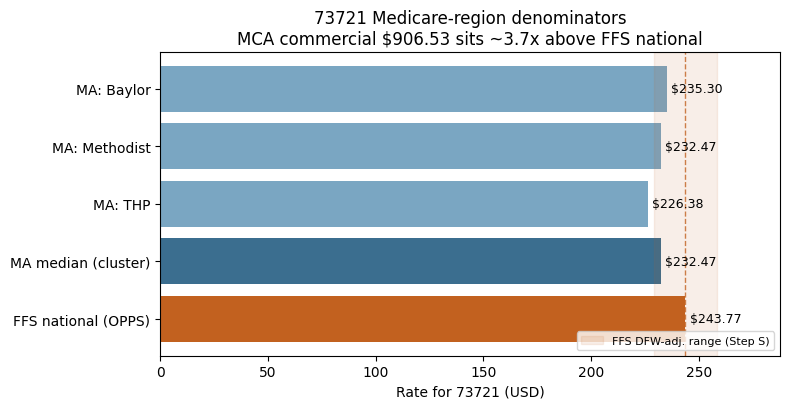

FFS national $243.77; DFW-adjusted band $229.14-$258.40 (Step S grid).
Parkland MA ($1,274.07) excluded from this view as a high outlier.


In [8]:
# Step V - Medicare-region denominators. Paste AFTER Step S. Needs matplotlib (same as NB9).
_need = ["PEER_MA", "national_73721", "PEER_MA_MEDIAN_CLUSTER", "sens"]
_missing = [n for n in _need if n not in globals()]
assert not _missing, f"Run Step S first. Missing: {_missing}"

import matplotlib.pyplot as plt

cluster = {k: v for k, v in PEER_MA.items() if k != "Parkland"}
labels = [f"MA: {k}" for k in cluster] + ["MA median (cluster)", "FFS national (OPPS)"]
values = list(cluster.values()) + [PEER_MA_MEDIAN_CLUSTER, national_73721]
colors = ["#7aa6c2"] * len(cluster) + ["#3b6e8f", "#c2611f"]

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(labels, values, color=colors)
ax.invert_yaxis()

ffs_lo, ffs_hi = float(sens.ffs_dfw_rate.min()), float(sens.ffs_dfw_rate.max())
ax.axvspan(ffs_lo, ffs_hi, color="#c2611f", alpha=0.10, label="FFS DFW-adj. range (Step S)")
ax.axvline(national_73721, color="#c2611f", ls="--", lw=1, alpha=0.8)

for b, v in zip(bars, values):
    ax.text(v + 2, b.get_y() + b.get_height() / 2, f"${v:,.2f}", va="center", fontsize=9)

ax.set_xlabel("Rate for 73721 (USD)")
ax.set_title("73721 Medicare-region denominators\nMCA commercial $906.53 sits ~3.7x above FFS national")
ax.set_xlim(0, max(values) * 1.18)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"FFS national ${national_73721:,.2f}; DFW-adjusted band ${ffs_lo:,.2f}-${ffs_hi:,.2f} (Step S grid).")
print("Parkland MA ($1,274.07) excluded from this view as a high outlier.")

In [9]:
# Investigation - the Parkland MA outlier ($1,274.07 for 73721).
_need = ["PEER_MA", "PEER_MA_MEDIAN_CLUSTER", "MCA_COMMERCIAL_USD", "national_73721", "pd"]
_missing = [n for n in _need if n not in globals()]
assert not _missing, f"Run Steps 0-3 first (Restart & Run All). Missing: {_missing}"

PARKLAND_MA  = PEER_MA["Parkland"]      # 1274.07 (NB10 Step R)
PEER_MEDIAN  = PEER_MA_MEDIAN_CLUSTER   # 232.47
MCA_COMM     = MCA_COMMERCIAL_USD       # 906.53
FFS_NATIONAL = national_73721           # 243.77 (OPPS technical/facility rate)

print(f"Parkland MA          : ${PARKLAND_MA:,.2f}")
print(f"  / peer-MA cluster  : {PARKLAND_MA/PEER_MEDIAN:5.2f}x  (${PEER_MEDIAN:,.2f})")
print(f"  / MCA commercial   : {PARKLAND_MA/MCA_COMM:5.2f}x  (${MCA_COMM:,.2f})")
print(f"  / FFS national     : {PARKLAND_MA/FFS_NATIONAL:5.2f}x  (${FFS_NATIONAL:,.2f})")
print()

# (1) hypothesis triage on magnitude (runs now)
PC_TYPICAL = 75.0                 # ballpark MRI professional component (illustrative)
global_est = FFS_NATIONAL + PC_TYPICAL
charge_band = (1000, 3500)        # typical MRI gross-charge range (illustrative)

hyps = [
    ("Gross/chargemaster leaked into negotiated column",
     charge_band[0] <= PARKLAND_MA <= charge_band[1],
     f"$1,274 sits inside typical MRI gross-charge band ${charge_band[0]:,}-${charge_band[1]:,}"),
    ("Global rate (technical + professional)",
     PARKLAND_MA <= global_est * 1.3,
     f"global ~ FFS+PC ~ ${global_est:,.0f}; $1,274 is ~{PARKLAND_MA/global_est:.1f}x that -- too high"),
    ("Mismapped to a pricier code (e.g. 73723 w/ and w/o contrast)",
     None,
     "magnitude cannot decide -- check the description/CPT on the raw row"),
    ("Rate-type mislabel (max / list / expected vs negotiated)",
     None,
     "check the rate-type / methodology column on the raw row"),
    ("Single stray plan row treated as the hospital MA rung",
     None,
     "check how many MA rows Parkland has for 73721 and their spread"),
]
print("Hypothesis triage (magnitude only):")
for name, supported, note in hyps:
    tag = "LIKELY" if supported is True else ("UNLIKELY" if supported is False else "CHECK RAW")
    print(f"  [{tag:9}] {name}")
    print(f"             -> {note}")
print()
print("Leading hypothesis on magnitude: gross/chargemaster leak. Confirm against the raw row in part (2).")
print()

# (2) raw-row diagnostic. Pull Parkland's 73721 rate rows from your DB (NB9/NB10 query layer)
#     into a DataFrame `parkland_raw`, then call diagnose_parkland(parkland_raw).
#     Column names are GUESSES -- map them to your MRF schema in COLMAP.
COLMAP = {
    "code": "code", "description": "description", "rate": "rate",
    "rate_type": "rate_type", "payer": "payer", "plan": "plan",
    "setting": "setting", "modifier": "modifier",
}

def diagnose_parkland(df, colmap=COLMAP, target_value=PARKLAND_MA):
    if df is None or len(df) == 0:
        print("no rows passed -- pull Parkland 73721 rows into a DataFrame and pass them in.")
        return
    cols = {k: v for k, v in colmap.items() if v in df.columns}
    missing = [k for k, v in colmap.items() if v not in df.columns]
    print(f"rows: {len(df)}; mapped cols: {sorted(cols)}; not present: {missing}")
    print()

    if "rate" in cols:
        r = cols["rate"]
        hit = df[df[r].round(2) == round(target_value, 2)]
        print(f"row(s) equal to ${target_value:,.2f}: {len(hit)}")
        show = [cols[k] for k in ("code","description","rate","rate_type","payer","plan","setting","modifier") if k in cols]
        if len(hit):
            print(hit[show].to_string(index=False))
        print()

    if "code" in cols:
        print("code value counts (is it really 73721?):")
        print(df[cols["code"]].astype(str).value_counts().to_string())
        print()

    if "rate_type" in cols:
        print("rate_type value counts (is 1274.07 a 'negotiated' value?):")
        print(df[cols["rate_type"]].astype(str).value_counts().to_string())
        print()

    if "rate" in cols:
        print("rate distribution for these rows:")
        print(df[cols["rate"]].describe().to_string())
        print()
        print("If 1274.07 is one stray row amid ~$230 rows, the rung should be Parkland's own")
        print("median negotiated MA rate, not this single value.")

# Example (uncomment once you have the rows):
# parkland_raw = <your query: Parkland, code 73721, all rate rows>
# diagnose_parkland(parkland_raw)
print("scaffold ready -- pull `parkland_raw`, then call diagnose_parkland(parkland_raw).")

Parkland MA          : $1,274.07
  / peer-MA cluster  :  5.48x  ($232.47)
  / MCA commercial   :  1.41x  ($906.53)
  / FFS national     :  5.23x  ($243.77)

Hypothesis triage (magnitude only):
  [LIKELY   ] Gross/chargemaster leaked into negotiated column
             -> $1,274 sits inside typical MRI gross-charge band $1,000-$3,500
  [UNLIKELY ] Global rate (technical + professional)
             -> global ~ FFS+PC ~ $319; $1,274 is ~4.0x that -- too high
  [CHECK RAW] Mismapped to a pricier code (e.g. 73723 w/ and w/o contrast)
             -> magnitude cannot decide -- check the description/CPT on the raw row
  [CHECK RAW] Rate-type mislabel (max / list / expected vs negotiated)
             -> check the rate-type / methodology column on the raw row
  [CHECK RAW] Single stray plan row treated as the hospital MA rung
             -> check how many MA rows Parkland has for 73721 and their spread

Leading hypothesis on magnitude: gross/chargemaster leak. Confirm against the raw row in 

In [10]:
# Parkland outlier - VERDICT. Run after you have `parkland_raw` (Parkland's 73721 rows that the
# classifier put in the MA bucket) and after the investigation cell (needs COLMAP, PARKLAND_MA).
_need = ["COLMAP", "PARKLAND_MA", "PEER_MA", "PEER_MA_MEDIAN_ALL", "pd"]
_missing = [n for n in _need if n not in globals()]
assert not _missing, f"Run the investigation cell + Step 3 first. Missing: {_missing}"

def _is_negotiated(rt):
    t = str(rt).strip().lower()
    if any(k in t for k in ("gross","charge","list","cash","self","max","expected","min")):
        return False
    if any(k in t for k in ("negotiat","contract","allow")):
        return True
    return None  # unrecognized vocabulary -> inspect manually

def verdict_parkland(df, colmap=COLMAP, target_value=PARKLAND_MA):
    assert df is not None and len(df), "pass Parkland's 73721 MA-candidate rows"
    cols = {k: v for k, v in colmap.items() if v in df.columns}
    need = [c for c in ("rate","code","rate_type") if c not in cols]
    if need:
        print(f"cannot reach a verdict -- missing column(s): {need}. Map them in COLMAP.")
        return

    r, c, rt = cols["rate"], cols["code"], cols["rate_type"]
    work = df.copy()
    work[r] = pd.to_numeric(work[r], errors="coerce")

    hit = work[work[r].round(2) == round(target_value, 2)]
    spike = hit.iloc[0] if len(hit) else work.loc[work[r].idxmax()]
    spike_rt, spike_code = spike[rt], str(spike[c]).strip()
    neg_flag = _is_negotiated(spike_rt)

    is_neg = work[rt].map(_is_negotiated) == True
    is_721 = work[c].astype(str).str.strip() == "73721"
    clean = work[is_neg & is_721]
    corrected = float(clean[r].median()) if len(clean) else None

    print(f"spike row -> ${spike[r]:,.2f} | code {spike_code} | rate_type '{spike_rt}'")
    print(f"genuinely-negotiated 73721 rows: {len(clean)}"
          + (f"; median = ${corrected:,.2f}" if corrected is not None else ""))
    print()

    if neg_flag is False:
        v = ("A: LEAK", "a non-negotiated value was classified into the MA bucket")
    elif spike_code != "73721":
        v = ("B: MISMAP", f"the spike row is code {spike_code}, not 73721")
    elif len(clean) > 1:
        v = ("C: STRAY SPIKE", "a single high negotiated row was picked as the rung instead of the median")
    elif len(clean) == 1:
        v = ("D: GENUINE", "Parkland's only negotiated MA rate for 73721 -- real, just anomalous")
    else:
        v = ("?: INSPECT", f"rate_type '{spike_rt}' not recognized -- read the raw row")

    print(f"VERDICT {v[0]} -- {v[1]}")
    if v[0][0] in ("A","C") and corrected is not None:
        print(f"  Fix: set Parkland's MA rung to its negotiated median ${corrected:,.2f} (was ${target_value:,.2f}).")
        peers = [vv for k, vv in PEER_MA.items() if k != "Parkland"]
        a = sorted(peers + [corrected]); n = len(a)
        new_med = a[n//2] if n % 2 else (a[n//2-1] + a[n//2]) / 2
        print(f"  Peer-MA median (all four, Parkland corrected) -> ${new_med:,.2f} (was ${PEER_MA_MEDIAN_ALL:,.2f}).")
    elif v[0][0] == "B":
        print("  Fix: correct the code filter so only true 73721 rows feed the rung.")
    elif v[0][0] == "D":
        print("  Keep the cluster median (Parkland excluded) as the robust figure; footnote the outlier.")

# verdict_parkland(parkland_raw)
print("verdict helper ready -- call verdict_parkland(parkland_raw).")

verdict helper ready -- call verdict_parkland(parkland_raw).
